# # Methods to Handle Missing Dataset
- Imputation  --> Using some statical val(mean,median,mode) and replacing with missing val
- Dropping  --> Means dropping the missing val when dataset is large

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
placement_df = pd.read_csv(r'C:\Users\HP\OneDrive\Desktop\python\pyCourse\Notebooks\Placement_Dataset.csv')

In [ ]:
placement_df.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


In [ ]:
placement_df.shape

(215, 15)

Getting missing values:

In [ ]:
placement_df.isnull().sum()

sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64

Central Tendencies:
1. Mean --> Avg. of all val(sum of all/no of val)
2. Median  --> middle val after sorting values(for even add two middle val/2)
3. Mode  --> frequencies of val

- Mean : Fill missing val with mean when data is uniformly distributed
- Median : Fill missing val with median when data is skewed 
- Mode : Fill missing val with mode when data is skewed and have categorical values 

C:\Users\HP\AppData\Local\Temp\ipykernel_11828\3044777043.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(placement_df.salary)


<Axes: xlabel='salary', ylabel='Density'>

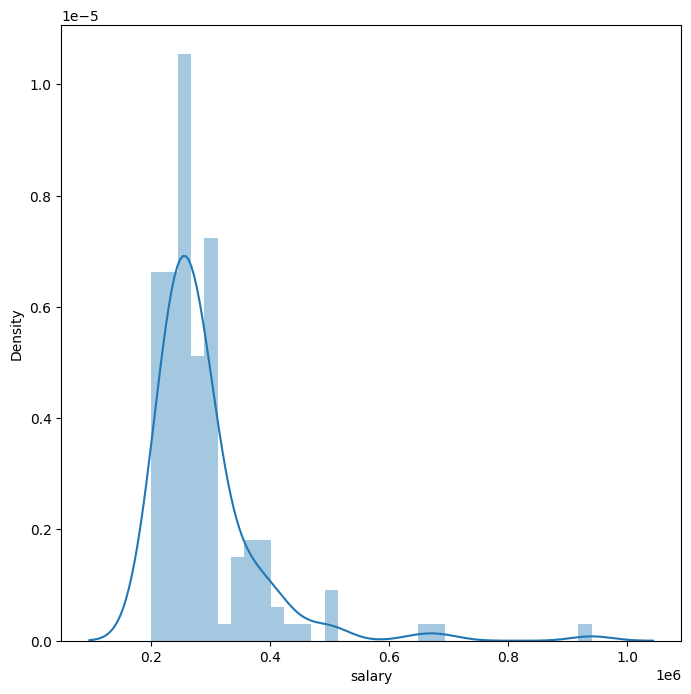

In [ ]:
# analysing salary by plotting it
fig, ax = plt.subplots(figsize=(8,8))
sns.distplot(placement_df.salary)

WHAT AND WHEN TO USE TO REPLACE MISSING VAL:
- When data is distributed in one side, then that is skew data. So we can't use Mean as it will be inconsistent distributn, therefore we can use Median/Mode.

- But when values are evenly distributed values, then we can use Mean.

# Replacing missing values

a. Filling missing values with median

In [ ]:
placement_df['salary'].fillna(placement_df['salary'].median(), inplace=True)

In [ ]:
placement_df.isnull().sum()

sl_no             0
gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
salary            0
dtype: int64

b. Filling missing values with mean

In [ ]:
# placement_df['salary'].fillna(placement_df['salary'].mean(), inplace=True)

# Dropping the missing val

In [ ]:
salary_dataset = pd.read_csv(r'C:\Users\HP\OneDrive\Desktop\python\pyCourse\Notebooks\Placement_Dataset.csv')

In [ ]:
salary_dataset.shape

(215, 15)

In [ ]:
salary_dataset.isnull().sum()

sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64

In [ ]:
# dropping missing val (here na - not available)
salary_dataset = salary_dataset.dropna(how='any')

In [ ]:
salary_dataset.isnull().sum()

sl_no             0
gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
salary            0
dtype: int64

In [ ]:
salary_dataset.shape

(148, 15)

# # DATA STANDARDIZATION

- It is a data pre-processing process for standardizing the data to a common format and common range

In [ ]:
import numpy as np
import pandas as pd
import sklearn.datasets
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
# loading dataset
dataset = sklearn.datasets.load_breast_cancer()

In [ ]:
print(dataset)

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]], shape=(569, 30)), 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0,

In [ ]:
cancer_df = pd.DataFrame(dataset.data, columns=dataset.feature_names)

In [ ]:
cancer_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
cancer_df.shape

(569, 30)

Splitting data before Standardizing data

In [ ]:
x = cancer_df  # it contains features name
y = dataset.target # it contains target val

# Splitting data into training data & testing data

Outlayers are those values which are abnormal in nature
- And if data have outlayers and we standarized data before splitting, it'll cause problem
- So split before standarizing
- 80% for training and 20% for testing/evaluation 

In [ ]:
# give x(f.n),y(target),ts(20%),rs to train fn
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=3)

In [ ]:
print(x.shape, x_test.shape, x_train.shape)

(569, 30) (114, 30) (455, 30)


# Standardize the data:

In [ ]:
print(dataset.data.std())

228.29740508276657


WHEN TO STANDARDISE DATA:
- When std() of data is far far away from 1, it means there is no similarity in data, so we need to Standardize it

In [ ]:
scaler = StandardScaler()

WHAT SRANDARDSCALER FN DO:
- Formula: z = (x-u)/s 
- Means each data pts(x) is taken and mean is subs from it and then divided by variance

In [ ]:
scaler.fit(x_train)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [ ]:
x_train_standardize = scaler.transform(x_train)

In [ ]:
print(x_train_standardize)

[[ 1.40381088  1.79283426  1.37960065 ...  1.044121    0.52295995
   0.64990763]
 [ 1.16565505 -0.14461158  1.07121375 ...  0.5940779   0.44153782
  -0.85281516]
 [-0.0307278  -0.77271123 -0.09822185 ... -0.64047556 -0.31161687
  -0.69292805]
 ...
 [ 1.06478904  0.20084323  0.89267396 ...  0.01694621  3.06583565
  -1.29952679]
 [ 1.51308238  2.3170559   1.67987211 ...  1.14728703 -0.16599653
   0.82816016]
 [-0.73678981 -1.02636686 -0.74380549 ... -0.31826862 -0.40713129
  -0.38233653]]


In [ ]:
x_test_standardize = scaler.transform(x_test)

In [ ]:
print(x_train_standardize.std())

1.0


In [ ]:
print(x_test_standardize.std())

0.8654541077212674


Here std = 1 means all data are in similar range and does not affect nature of dataset

# How to standardize data:
- Firstly split data into x,y or Make x(feature name), y(target)
- Then split data into test & training data using train_test_split (featureN, target, ts, rs) fn
- Now make scaler using StandradScaler fn
- Now fit the data using fit and fit only that data which is larger(like x_train)
- Now standardise test & train data using transform fn
- And if std of that standardise data is 1 or close to it, it means similar

# # LABEL ENCODING:
- CONVERTING THE LABELS INTO NUMBERIC FORM
- In this when label is defined in symbols as M,B,etc then we convert labels data into 0&1 for better ml model understanding

In [1]:
# importing dependecies
import pandas as pd
from sklearn.preprocessing import LabelEncoder

Label Encoding of Breast Cancer dataset

In [3]:
bCancer_data = pd.read_csv(r'C:\Users\HP\OneDrive\Desktop\python\pyCourse\Notebooks\data.csv')

In [4]:
bCancer_data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [5]:
# finding count of diff labels
bCancer_data['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

In [6]:
# load the label encoder fn
label_encode = LabelEncoder()

In [7]:
# converting labels into 0&1 label
labels = label_encode.fit_transform(bCancer_data.diagnosis)

In [8]:
# appending labels to df
bCancer_data['target'] = labels

In [9]:
bCancer_data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32,target
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN,1
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN,1
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN,1
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN,1
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN,1


In [10]:
# 0 --> Benign
# 1 --> Malignant

bCancer_data['target'].value_counts()

target
0    357
1    212
Name: count, dtype: int64

Loading iris dataset

In [11]:
iris_data = pd.read_csv(r'C:\Users\HP\OneDrive\Desktop\python\pyCourse\Notebooks\iris_data.csv')

In [12]:
iris_data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [13]:
iris_data['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [14]:
iLab_encoder = LabelEncoder()

In [15]:
lab = iLab_encoder.fit_transform(iris_data.Species)

In [16]:
iris_data['target'] = lab

In [18]:
iris_data.tail()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,target
145,146,6.7,3.0,5.2,2.3,Iris-virginica,2
146,147,6.3,2.5,5.0,1.9,Iris-virginica,2
147,148,6.5,3.0,5.2,2.0,Iris-virginica,2
148,149,6.2,3.4,5.4,2.3,Iris-virginica,2
149,150,5.9,3.0,5.1,1.8,Iris-virginica,2


# SUMMARY
- Firstly, from sklearn.preprocessing import LabelEncoder
- import csv file
- findout value count of that label we need to encode
- store labelEncoder fn into var
- then convert labels into 0&1 usinf fittransform fn and store in a var
- now, append labels to data frame

# # ML PROJECT WORkFLOW
- Collecting the appropriate data
- Data PreProcessing occurs
- Then Analysis of data
- Spliting data into train & test data
- Now we feed data to ML model
- After model training, Evalution of model occurs

# # Handling Imbalanced Dataset
- A dataset with an unequal class distribution
- Ex: like if we have 1000 diab patient and 100 non-diab, then it is imbalanced dataset and cause problem

In [9]:
# importing csv file
credit_card = pd.read_csv(r'C:\Users\HP\OneDrive\Desktop\python\pyCourse\Notebooks\credit_data.csv')

In [10]:
credit_card.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [11]:
credit_card.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,-1.593105,2.711941,-0.689256,4.626942,-0.924459,1.107641,1.991691,0.510632,-0.682920,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,-0.150189,0.915802,1.214756,-0.675143,1.164931,-0.711757,-0.025693,-1.221179,-1.545556,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,0.411614,0.063119,-0.183699,-0.510602,1.329284,0.140716,0.313502,0.395652,-0.577252,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,-1.933849,-0.962886,-1.042082,0.449624,1.962563,-0.608577,0.509928,1.113981,2.897849,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,-0.915427,-1.040458,-0.031513,-0.188093,-0.084316,0.041333,-0.302620,-0.660377,0.167430,-0.256117,0.382948,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


- 0 --> for legit
- 1 --> for fraudalant

In [ ]:
# This is highly imbalanced dataset
credit_card['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [ ]:
# distributing data into legit and fraud transctn
legit = credit_card[credit_card.Class == 0]
fraud = credit_card[credit_card.Class == 1]

In [14]:
print(legit.shape)
print(fraud.shape)

(284315, 31)
(492, 31)


UNDER-SAMPLING:
- Build a sample dataset containing similar(can or cannot be equal means in similar range) distribution of legit & fradualent transactions

In [15]:
# No of fraud transactn -> 492
legit_sample = legit.sample(n=500)

Concatenate the two df

In [16]:
new_card_dataset = pd.concat([legit_sample, fraud], axis=0)

In [19]:
new_card_dataset.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
218881,141505.0,2.072626,0.174801,-1.641449,0.458446,0.386487,-0.857132,0.126975,-0.297822,0.777896,-0.625351,-0.903714,0.558574,1.119999,-1.270211,0.399141,0.320356,0.255853,0.368776,0.041744,-0.119297,-0.093057,0.001312,0.040509,-0.727546,0.135679,-0.302284,0.022994,-0.026299,4.81,0
97748,66365.0,0.188229,1.166929,-0.083609,0.751499,0.882265,-0.632985,1.124146,-0.301631,-0.694298,0.153899,-1.033418,0.466100,1.590058,0.155764,0.567794,-0.379622,-0.534946,-0.021840,0.684844,0.210546,0.108024,0.573073,-0.066123,-0.413951,-0.542798,-0.368349,0.441913,0.226807,17.99,0
95987,65553.0,-0.292681,-0.806033,2.842521,-0.841919,-1.279412,1.198062,-0.866667,0.415456,0.242822,0.091741,0.481075,0.162418,-0.631630,-1.543113,-2.426329,0.116409,1.014491,-1.238640,1.212572,0.210520,0.214949,1.066314,-0.145420,0.082730,-0.050918,-0.101889,-0.054032,-0.200946,47.50,0
98442,66663.0,-0.527216,1.447727,1.400645,2.505610,1.064884,0.880813,0.696465,0.046814,-1.883937,0.783723,0.098713,0.519663,1.249522,0.063964,-0.395528,-0.158576,-0.346123,0.527671,1.874265,0.225686,0.012411,0.137318,-0.562136,-0.774807,0.571592,0.411204,-0.054498,0.049861,0.76,0
69176,53301.0,-2.423090,0.002590,1.778551,-1.197764,1.355823,-0.417638,-1.026683,-0.428347,0.135782,0.053022,1.767201,0.905076,-0.230285,0.155693,0.637301,0.163818,-0.192538,-0.839183,-0.867693,-0.579320,0.549136,-0.428799,-1.017931,-0.167035,-0.136833,0.892118,0.553089,0.090010,20.00,0


In [20]:
new_card_dataset.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
279863,169142.0,-1.927883,1.125653,-4.518331,1.749293,-1.566487,-2.010494,-0.882850,0.697211,-2.064945,-5.587794,2.115795,-5.417424,-1.235123,-6.665177,0.401701,-2.897825,-4.570529,-1.315147,0.391167,1.252967,0.778584,-0.319189,0.639419,-0.294885,0.537503,0.788395,0.292680,0.147968,390.00,1
280143,169347.0,1.378559,1.289381,-5.004247,1.411850,0.442581,-1.326536,-1.413170,0.248525,-1.127396,-3.232153,2.858466,-3.096915,-0.792532,-5.210141,-0.613803,-2.155297,-3.267116,-0.688505,0.737657,0.226138,0.370612,0.028234,-0.145640,-0.081049,0.521875,0.739467,0.389152,0.186637,0.76,1
280149,169351.0,-0.676143,1.126366,-2.213700,0.468308,-1.120541,-0.003346,-2.234739,1.210158,-0.652250,-3.463891,1.794969,-2.775022,-0.418950,-4.057162,-0.712616,-1.603015,-5.035326,-0.507000,0.266272,0.247968,0.751826,0.834108,0.190944,0.032070,-0.739695,0.471111,0.385107,0.194361,77.89,1
281144,169966.0,-3.113832,0.585864,-5.399730,1.817092,-0.840618,-2.943548,-2.208002,1.058733,-1.632333,-5.245984,1.933520,-5.030465,-1.127455,-6.416628,0.141237,-2.549498,-4.614717,-1.478138,-0.035480,0.306271,0.583276,-0.269209,-0.456108,-0.183659,-0.328168,0.606116,0.884876,-0.253700,245.00,1
281674,170348.0,1.991976,0.158476,-2.583441,0.408670,1.151147,-0.096695,0.223050,-0.068384,0.577829,-0.888722,0.491140,0.728903,0.380428,-1.948883,-0.832498,0.519436,0.903562,1.197315,0.593509,-0.017652,-0.164350,-0.295135,-0.072173,-0.450261,0.313267,-0.289617,0.002988,-0.015309,42.53,1


In [18]:
new_card_dataset['Class'].value_counts()

Class
0    500
1    492
Name: count, dtype: int64

# SUMMARY
- Import the csv file
- find value count of label to recognise it as imbalanced dataset
- Separate that label values in 0 & 1 grp
- Do under sampling of that label by making similar sample of legit transactns
- Now concatenate the fraud sample & legit sample into new df

# # FEATURE EXTRACTION
- The mapping from textual data to real valued vectors is called feature extraction
- Text data is harder to understand for ml model whereas numeric data is easy, so here to convert textual data to numeric data
- Here feature vectors are numerical representatn of textual val

Terminologies:
- BOW(Bag of Words): list of unique words in text corpus(collection of words)
- TF-IDF(Term Freq-Inverse Document Freq): To count the no of times each words appears in a docs

Tf-idf Vectorizer: 
- TF(Term Freq) = (No of times termt appears in a docs)/(No of terms in docs)
- IDF = log(N/n), where N is no of docs & n is no of docs a term t has appeared in
- the IDF value of rare word is high, where IDF of frequent word(like are, here, the,etc) is low.
- TF-IDF val of a term == TF * IDF

HOW TO DO IT:
- from sklearn.feature_extractn.text import TfidfVectorizer
- Convert textual data to feature vectors as: vectorizer = TfidfVectorizer()
- Now fit and transform data where these fn will count no of words and give numeric values to them as: vectorizer.fit(x) & x = vectorizer.transform(x)
- Now print and we will see dataset is vectorized in numeric form

# # Numerical Dataset Pre-Processing

In [1]:
# importing dependencies
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
db_data = pd.read_csv(r'C:\Users\HP\OneDrive\Desktop\python\pyCourse\Notebooks\diabetes.csv')

In [3]:
db_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Separating features(all labels except target) and target label:

In [4]:
x = db_data.drop(columns='Outcome', axis=1)
y = db_data['Outcome']

In [5]:
print(x)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


In [6]:
print(y)

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64


In [7]:
y.value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

# Data standardization before splitting:
- if we standardie data before splitting, it will have original range of data
- and if we do splitting first, some data may loose

In [8]:
scal = StandardScaler()

In [9]:
stand_data = scal.fit_transform(x)

In [10]:
print(stand_data)

[[ 0.63994726  0.84832379  0.14964075 ...  0.20401277  0.46849198
   1.4259954 ]
 [-0.84488505 -1.12339636 -0.16054575 ... -0.68442195 -0.36506078
  -0.19067191]
 [ 1.23388019  1.94372388 -0.26394125 ... -1.10325546  0.60439732
  -0.10558415]
 ...
 [ 0.3429808   0.00330087  0.14964075 ... -0.73518964 -0.68519336
  -0.27575966]
 [-0.84488505  0.1597866  -0.47073225 ... -0.24020459 -0.37110101
   1.17073215]
 [-0.84488505 -0.8730192   0.04624525 ... -0.20212881 -0.47378505
  -0.87137393]]


In [11]:
x = stand_data

In [13]:
xTrain, xTest, yTrain, yTest = train_test_split(x,y, test_size=0.2, random_state=2)

In [14]:
print(x.shape, xTrain.shape, xTest.shape)

(768, 8) (614, 8) (154, 8)


# # Text Data Pre-Processing Tutorial

Project Workflow:
- News Data   -->   Data pre processing   -->   Train test split   -->   Logistic Regression Model(because we deal with binary(2) outcomes or values)    -->   Trained LRM    -->   New Data is feed and then model evaluate it

In [22]:
import numpy as np
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

Downloading stopwords and printing them

In [3]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

STOPWORDS:
- those words which don't convey any meaning and repeated most of the times in text
- So we remove these words from our dataset
- So that's why we have downloaded them

In [4]:
# printing the stopwords
print(stopwords.words('english'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

- Data preprocessing

In [37]:
# importing csv file
news_data = pd.read_csv(r'C:\Users\HP\OneDrive\Desktop\python\pyCourse\csvFiles\train.csv')

In [6]:
news_data.head()

,id,title,author,text,label
0,0,House Dem Aide: We Didn’t Even See Comey’s Let...,Darrell Lucus,House Dem Aide: We Didn’t Even See Comey’s Let...,1
1,1,"FLYNN: Hillary Clinton, Big Woman on Campus - ...",Daniel J. Flynn,Ever get the feeling your life circles the rou...,0
2,2,Why the Truth Might Get You Fired,Consortiumnews.com,"Why the Truth Might Get You Fired October 29, ...",1
3,3,15 Civilians Killed In Single US Airstrike Hav...,Jessica Purkiss,Videos 15 Civilians Killed In Single US Airstr...,1
4,4,Iranian woman jailed for fictional unpublished...,Howard Portnoy,Print \nAn Iranian woman has been sentenced to...,1


In [7]:
# finding missing values
news_data.isnull().sum()

id           0
title      558
author    1957
text        39
label        0
dtype: int64

- Here in this dataset, it is not effiecient to put mode,mean values in missing val or we can't find them
- So we put null string in it

In [5]:
news_data = news_data.fillna('')

As we want to process only to labels: author & title, So we merge both of them

In [6]:
news_data['Content'] = news_data['author']+' '+news_data['title']

In [7]:
news_data.head()

,id,title,author,text,label,Content
0,0,House Dem Aide: We Didn’t Even See Comey’s Let...,Darrell Lucus,House Dem Aide: We Didn’t Even See Comey’s Let...,1,Darrell Lucus House Dem Aide: We Didn’t Even S...
1,1,"FLYNN: Hillary Clinton, Big Woman on Campus - ...",Daniel J. Flynn,Ever get the feeling your life circles the rou...,0,"Daniel J. Flynn FLYNN: Hillary Clinton, Big Wo..."
2,2,Why the Truth Might Get You Fired,Consortiumnews.com,"Why the Truth Might Get You Fired October 29, ...",1,Consortiumnews.com Why the Truth Might Get You...
3,3,15 Civilians Killed In Single US Airstrike Hav...,Jessica Purkiss,Videos 15 Civilians Killed In Single US Airstr...,1,Jessica Purkiss 15 Civilians Killed In Single ...
4,4,Iranian woman jailed for fictional unpublished...,Howard Portnoy,Print \nAn Iranian woman has been sentenced to...,1,Howard Portnoy Iranian woman jailed for fictio...


- Separating features(all labels except target(label) label) and target(label)

In [8]:
x = news_data.drop(columns='label', axis=1)
y = news_data['label']

STEMMING:
- Stemming is the process of reducing a word to its keyword/Rootword.
- for this we use PortStemmer fn
- Ex: actor,actress, acting --> act

In [9]:
port_stem = PorterStemmer()

- Making a fn for removing stopwords present in the content label and converting those words which are not present into rootwords

In [ ]:
def stemming(Content):
    stemmed_content = re.sub('[^a-zA-Z]',' ', Content)   # this line will take all capital and small letter words and remove comas or any other symbols with space
    stemmed_content = stemmed_content.lower()  # it will convert all uppercase letter to lowercase and this lower() fn is of re lib
    stemmed_content = stemmed_content.split()   # it'll split all words
    stemmed_content = [port_stem.stem(word) for word in stemmed_content if not word in stopwords.words('english')]   # here we are removing all those words from content which are present in the stopwords as we don't need them and converting those words which are not present in stopwords into the rootwords
    stemmed_content = ' '.join(stemmed_content)
    return stemmed_content

In [10]:
# applying on news dataset
news_data['Content'] = news_data['Content'].apply(stemming)

In [11]:
print(news_data['Content'])

0        darrel lucu hous dem aid even see comey letter...
1        daniel j flynn flynn hillari clinton big woman...
2                   consortiumnew com truth might get fire
3        jessica purkiss civilian kill singl us airstri...
4        howard portnoy iranian woman jail fiction unpu...
                               ...                        
20795    jerom hudson rapper trump poster child white s...
20796    benjamin hoffman n f l playoff schedul matchup...
20797    michael j de la merc rachel abram maci said re...
20798    alex ansari nato russia hold parallel exercis ...
20799                            david swanson keep f aliv
Name: Content, Length: 20800, dtype: object


In [12]:
# separating features and target from content
x = news_data['Content'].values
y = news_data['label'].values

In [13]:
print(x)

['darrel lucu hous dem aid even see comey letter jason chaffetz tweet'
 'daniel j flynn flynn hillari clinton big woman campu breitbart'
 'consortiumnew com truth might get fire' ...
 'michael j de la merc rachel abram maci said receiv takeov approach hudson bay new york time'
 'alex ansari nato russia hold parallel exercis balkan'
 'david swanson keep f aliv']


In [14]:
print(y)

[1 0 1 ... 0 1 1]


In [21]:
y.shape

(20800,)

- Now do feature extraction by converting text values to its feature vectors

In [16]:
# converting textual data to feature vector
vectoriz = TfidfVectorizer()
vectoriz.fit(x)

x = vectoriz.transform(x)

In [17]:
print(x)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 210687 stored elements and shape (20800, 17128)>
  Coords	Values
  (0, 267)	0.2701012497770876
  (0, 2483)	0.36765196867972083
  (0, 2959)	0.24684501285337127
  (0, 3600)	0.3598939188262558
  (0, 3792)	0.27053324808454915
  (0, 4973)	0.23331696690935097
  (0, 7005)	0.2187416908935914
  (0, 7692)	0.24785219520671598
  (0, 8630)	0.2921251408704368
  (0, 8909)	0.36359638063260746
  (0, 13473)	0.2565896679337956
  (0, 15686)	0.2848506356272864
  (1, 1497)	0.2939891562094648
  (1, 1894)	0.15521974226349364
  (1, 2223)	0.3827320386859759
  (1, 2813)	0.19094574062359204
  (1, 3568)	0.26373768806048464
  (1, 5503)	0.7143299355715573
  (1, 6816)	0.1904660198296849
  (1, 16799)	0.30071745655510157
  (2, 2943)	0.3179886800654691
  (2, 3103)	0.46097489583229645
  (2, 5389)	0.3866530551182615
  (2, 5968)	0.3474613386728292
  (2, 9620)	0.49351492943649944
  :	:
  (20797, 3643)	0.2115550061362374
  (20797, 7042)	0.21799048897828685
  (2079

Splitting data into test & train data

In [20]:
# stratify fn helps in distributing labels in equal proportion(equal fake & real news proportion)
xTr, xTs, yTr, yTs = train_test_split(x,y, test_size=0.2,stratify=y, random_state=2) 

In [21]:
print(x.shape, xTr.shape, xTs.shape)

(20800, 17128) (16640, 17128) (4160, 17128)


# Training the Model: Logistic Regression

Logistic Regression Model:
- It can be used to train data for binomial classification
- y = 1 / (1 + e^-z) : Sigmoid Equation
- z = w.x + b
- Here: x = input feature(vectoriz data), y = Predictn Probab(b/w 0 & 1), w = wghts(it estimate how important a label is), b = biases(intercept)
- Here, 0.5 is the threshold val of model
- If val is greater than 0.5 (like 0.8), it will give value as 1
- If val is less than 0.5 (like 0.3), it will give value as 0

In [23]:
model = LogisticRegression()

In [25]:
# this fit fn will train the model based on this training data
model.fit(xTr, yTr)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

- EVALUATION

Accuracy score:

In [26]:
# Accuracy score on the training data
xTr_predictn = model.predict(xTr)
training_data_accuracy = accuracy_score(xTr_predictn, yTr)

In [27]:
print('Accuracy of training data: ', training_data_accuracy)

Accuracy of training data:  0.9863581730769231


In [28]:
# Accuracy score on the testing data
xTs_predictn = model.predict(xTs)
testing_data_accuracy = accuracy_score(xTs_predictn, yTs)

In [29]:
print('Accuracy of testing data: ', testing_data_accuracy)

Accuracy of testing data:  0.9790865384615385


- Accuracy of training & testing data is almost 98%
- That's good accuracy |

- MAKING A PREDICTIVE SYSTEM

In [36]:
x_new = xTs[123]

prediction = model.predict(x_new)
print(prediction)

if (prediction[0] == 0):
    print('The news is Real')
else:
    print('The news is Fake')

[0]
The news is Real


In [35]:
print(yTs[123])

0


# # ALL THE FNS USED IN THE DATA PRE-PROCESSING


- df.isnull().sum()   --> to find the missing values
- df['labelName'].fillna(df['labelName'].mean(), inpace=True)   --> to fill the missing val in specific label
- dataset = dataset.dropna(how='any')   --> to drop the missing val
- from sklearn.preprocessing import StandardScaler    --> to import standard scaler fn
- from sklearn.model_selection import train_test_split    --> to import traintestsplit fn
- x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, stratify=y, random_state=3)   --> to split training and testing data
- from sklearn.preprocessing import LabelEncoder   --> to import label encoder fn
- data['labelName'].value_counts()   --> to count no of the diff values present in specific label
- df.describe()    --> to find all statistical val
- x = df.drop(columns='colName', axis=1)   --> to drop a specific col from features names
- y = df['colNam']   --> to select specific col
- import re   --> to import fn of regular expression
- import nltk   --> to import natural lang toolkit
- from nltk.corpus import stopwords    --> to import stopwords from nltk word corpus/collection
- from nltk.stem.porter import PorterStemmer     --> to import port stemmer fn for reducing words to its rootword
- from sklearn.feature_extraction.text import TfidfVectorizer    --> to import vectorizer for feature extraction
- from sklearn.linear_model import LogisticRegression    -> to import logical regression model for performing opt on binomial classsifications
- from sklearn.metrics import accuracy_score    --> to import accuracy score fn for evaluation of the model based on train & test data
- stopwords   --> the words in the corpus which don't convey any meaning and can be removed
- dataset['Content'] = news_data['author']+' '+news_data['title']      --> to merge two colmns into single colmns

# # DATA PRE-PROCESSING TECHNIQUES:

# 1. METHODS TO HANLE MISSING DATASET
- IMPUTATION
- How :
-> placement_df['salary'].fillna(placement_df['salary'].median(), inplace=True)

- DROPPING
- How :
-> salary_dataset = salary_dataset.dropna(how='any')

# 2. SPLITTING DATA INTO TRAINING & TESTING
- HOW :
- x = cancer_df  # it contains features name
- y = dataset.target # it contains target val
- x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=3)

# 3. DATA STANDARDIZATION
- HOW :
- print(dataset.data.std())
- scaler = StandardScaler()
- scaler.fit(x_train)
- x_train_standardize = scaler.transform(x_train)

# 4. LABEL ENCODING
- IST WAY :
- from sklearn.preprocessing import LabelEncoder
- bCancer_data['diagnosis'].value_counts() 
- label_encode = LabelEncoder()
- labels = label_encode.fit_transform(bCancer_data.diagnosis)
- bCancer_data['target'] = labels

- 2ND WAY :
- titanic.replace({'Sex':{'male':0, 'female':1}, 'Embarked': {'S':0, 'C':1, 'Q':2}}, inplace=True)

# 5. HANDLING IMBALANCED DATSET
- HOW :
- credit_card['Class'].value_counts()   --> This is highly imbalanced dataset
- legit = credit_card[credit_card.Class == 0]
- fraud = credit_card[credit_card.Class == 1]  --> distributing data into legit and fraud transctn
- legit_sample = legit.sample(n=500)   --> UNDER SAMPLING OF DATA
- new_card_dataset = pd.concat([legit_sample, fraud], axis=0)   --> CONCATENATE

# 6. FEATURE EXTRACTION
- HOW :
- vectoriz = TfidfVectorizer()
- vectoriz.fit(x)
- x = vectoriz.transform(x)

# 7. NUMERICAL DATA PRE-PROCESSING
- HOW :
- x = db_data.drop(columns='Outcome', axis=1)
- y = db_data['Outcome']
- y.value_counts()

# 8. STEMMING
- HOW :
- news_data['Content'] = news_data['author']+' '+news_data['title']
- x = news_data.drop(columns='label', axis=1)
- y = news_data['label']
- port_stem = PorterStemmer()
- def stemming(Content):   --> MAKE A FN FOR STEMMING THE WORDS
- news_data['Content'] = news_data['Content'].apply(stemming)


# 9. TRAINING THE MODEL
- HOW :
- model = LogisticRegression()
- model.fit(xTr, yTr)

# 10. EVALUATING THE MODEL
- HOW : 
- xTr_predictn = model.predict(xTr)
- training_data_accuracy = accuracy_score(xTr_predictn, yTr)